In [1]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [5]:
from sklearn.metrics import confusion_matrix

In [9]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
# Load dataset
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (120, 4)
Test set shape: (30, 4)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize multinomial Logistic Regression classifier
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test data
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 93.33%


In [13]:
cm = confusion_matrix(y_test, lr_preds)

In [15]:
plt.figure(figsize=(5, 4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

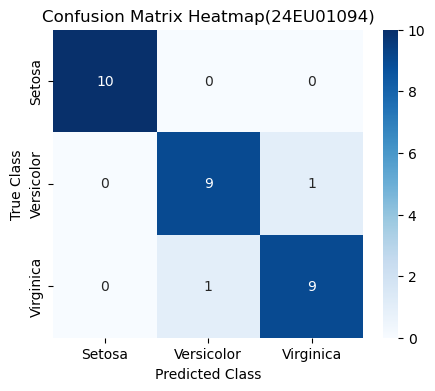

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix on Logistic Regression predictions
cm = confusion_matrix(y_test, lr_preds)

# Plot confusion matrix using a Seaborn heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap(24EU01094)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [25]:
from sklearn.metrics import classification_report

In [27]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

In [29]:
print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [31]:
from sklearn.preprocessing import label_binarize

In [33]:
from sklearn.metrics import roc_curve, auc

In [35]:
import matplotlib.pyplot as plt

In [37]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [39]:
y_score = lr_model.predict_proba(X_test)

In [41]:
plt.figure(figsize=(7,6))

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

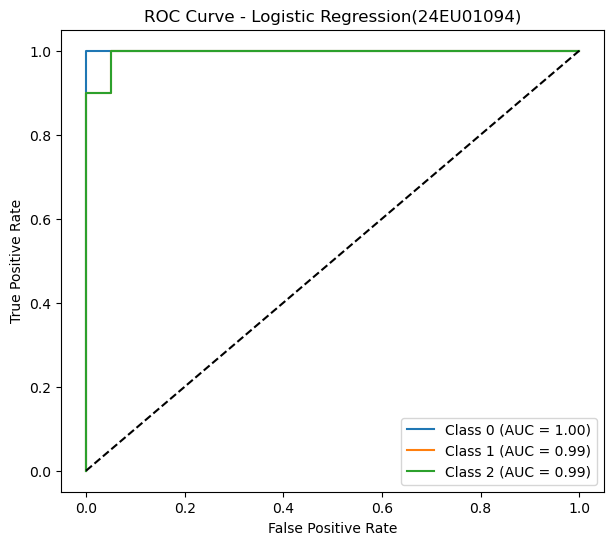

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities
y_score = lr_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression(24EU01094)")
plt.legend(loc="lower right")
plt.show()

In [45]:
from sklearn.datasets import load_iris

In [47]:
from sklearn.preprocessing import StandardScaler

In [49]:
from sklearn.linear_model import LogisticRegression

In [51]:
from sklearn.model_selection import cross_val_score

In [53]:
import numpy as np


In [55]:
iris = load_iris()

In [57]:
X = iris.data

In [59]:
y = iris.target

In [61]:
scaler = StandardScaler()

In [63]:
X_scaled = scaler.fit_transform(X)

In [65]:
lr_model = LogisticRegression(max_iter=200)

In [67]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)


In [69]:
print("5-Fold Cross-Validation Accuracy:")

5-Fold Cross-Validation Accuracy:


In [71]:
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000


In [73]:
print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))


Mean Accuracy: 96.00%
